# Can Your Team Chase 180? A Monte Carlo Approach to T20 Cricket

Every cricket fan has had this argument — *"180 is chaseable, the pitch is flat"* vs *"nobody averages 9 an over for 20 overs straight."*

Instead of arguing, I simulated it.

This notebook models a T20 run chase using **Monte Carlo simulation** — running thousands of virtual innings to estimate win, tie, and loss probabilities. It also works as an interactive tool: change the target, tweak the run rate, and see how the numbers shift.

I built this while studying probability distributions in Probability and Statistics course at IIT Kanpur. The math behind the simulation — Negative Binomial, Poisson, Law of Large Numbers — is what the course covers. Cricket just made it more interesting to work through.

---

**What you can do with this notebook:**
- Estimate win probability for any T20 target (just change `TARGET`)
- Understand why Negative Binomial fits cricket better than a simple average
- See the Law of Large Numbers converge in real time
- Run a sensitivity sweep across targets 120–220 to see the full picture

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

---
## Part 1 — The Model

### Why not just use the average?

The naive approach: if a team averages 8 runs per over, multiply by 20 and call it 160. Done.

The problem: cricket doesn't work like that. Real T20 innings have massive over-by-over variance — a single over can go for 5 or 25. This variation is called **overdispersion**, and it's why a simple average misses the point entirely.

The **Negative Binomial distribution** handles overdispersion naturally. It has two parameters — a mean and a dispersion term — so it can model both the average run rate *and* how unpredictable the scoring is. For wickets, the **Poisson distribution** is a good fit: wickets are rare events that happen mostly independently of each other.

### Simulation logic

Each simulated innings:
1. Loops through up to 20 overs
2. Samples runs and wickets for each over from the respective distributions
3. Stops early if the target is crossed (win) or all 10 wickets fall
4. Records the outcome as win / tie / loss

Run this 100,000 times and the proportion of wins gives you the win probability.

### Parameters — change these to explore

| Parameter | Default | What it controls |
|-----------|---------|------------------|
| `TARGET` | 180 | Runs needed to win — try 150, 170, 200 |
| `MU_RUNS` | 8 | Average runs per over — higher = stronger batting |
| `R_DISPERSION` | 2 | Scoring variance — lower = more unpredictable |
| `LAMBDA_WICKETS` | 0.42 | Wickets per over rate — higher = collapses more often |
| `N_TRIALS` | 100,000 | More trials = more stable estimate, slower run |

In [2]:
TARGET      = 180   # runs needed to win
MU_RUNS     = 8     # average runs per over
R_DISPERSION = 2    # overdispersion (lower = more variance in scoring)
LAMBDA_WICKETS = 0.42  # average wickets per over
N_TRIALS    = 100_000

# derived
OVERS       = 20
MAX_WICKETS = 10
P_NB        = R_DISPERSION / (R_DISPERSION + MU_RUNS)

rng = np.random.default_rng(42)

print(f'Chasing {TARGET} in {OVERS} overs')
print(f'Avg run rate: {MU_RUNS}/over  |  Wicket rate: {LAMBDA_WICKETS}/over')

Chasing 180 in 20 overs
Avg run rate: 8/over  |  Wicket rate: 0.42/over


---
## Part 2 — Understanding the Distributions

Before simulating full innings, let's look at what a single over looks like under each distribution. This is worth spending time on — the shape of these distributions is what drives the final results.

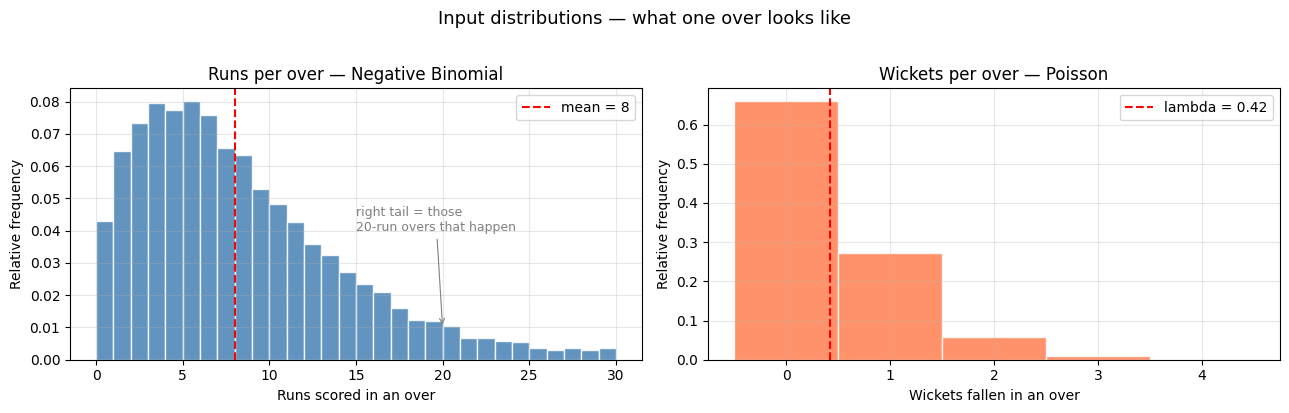

Runs  — mean: 8.11, std: 6.44, max seen: 54
Wickets — mean: 0.418, % overs with 0 wickets: 66.0%


In [3]:
sample_runs    = rng.negative_binomial(R_DISPERSION, P_NB, size=10_000)
sample_wickets = rng.poisson(LAMBDA_WICKETS, size=10_000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.hist(sample_runs, bins=range(0, 31), color='steelblue', edgecolor='white', alpha=0.85, density=True)
ax1.axvline(MU_RUNS, color='red', linestyle='--', linewidth=1.5, label=f'mean = {MU_RUNS}')
ax1.set_title('Runs per over — Negative Binomial', fontsize=12)
ax1.set_xlabel('Runs scored in an over')
ax1.set_ylabel('Relative frequency')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.annotate('right tail = those\n20-run overs that happen', xy=(20, 0.01),
             xytext=(15, 0.04), fontsize=9, color='gray',
             arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

ax2.hist(sample_wickets, bins=range(0, 6), color='coral', edgecolor='white',
         alpha=0.85, density=True, align='left')
ax2.axvline(LAMBDA_WICKETS, color='red', linestyle='--', linewidth=1.5, label=f'lambda = {LAMBDA_WICKETS}')
ax2.set_title('Wickets per over — Poisson', fontsize=12)
ax2.set_xlabel('Wickets fallen in an over')
ax2.set_ylabel('Relative frequency')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Input distributions — what one over looks like', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Runs  — mean: {sample_runs.mean():.2f}, std: {sample_runs.std():.2f}, max seen: {sample_runs.max()}')
print(f'Wickets — mean: {sample_wickets.mean():.3f}, % overs with 0 wickets: {(sample_wickets==0).mean()*100:.1f}%')

## Part 3 — Running the Simulation

In [4]:
# outcome encoding: 1 = win, 0.5 = tie, 0 = loss
outcomes     = np.zeros(N_TRIALS)
final_scores = np.zeros(N_TRIALS)

for t in range(N_TRIALS):
    runs    = 0
    wickets = 0

    for over in range(OVERS):
        runs_over    = rng.negative_binomial(R_DISPERSION, P_NB)
        wickets_over = rng.poisson(LAMBDA_WICKETS)
        wickets_over = min(wickets_over, MAX_WICKETS - wickets)  # can't lose more wickets than remaining

        runs    += runs_over
        wickets += wickets_over

        if runs > TARGET:           # chased it down
            outcomes[t] = 1
            break

        if wickets >= MAX_WICKETS:  # all out
            break

    if outcomes[t] == 0 and runs == TARGET:
        outcomes[t] = 0.5           # tied

    final_scores[t] = runs

print(f'{N_TRIALS:,} innings simulated.')

100,000 innings simulated.


## Part 4 — Results

### Win / Tie / Loss probabilities

In [5]:
P_win  = np.mean(outcomes == 1)
P_tie  = np.mean(outcomes == 0.5)
P_loss = np.mean(outcomes == 0)

print(f'Chasing {TARGET} | avg {MU_RUNS} runs/over | {N_TRIALS:,} trials')
print()
print(f'  Win  : {P_win*100:.1f}%')
print(f'  Tie  : {P_tie*100:.1f}%')
print(f'  Loss : {P_loss*100:.1f}%')
print()
print(f'  Total: {(P_win + P_tie + P_loss):.6f}')  # sanity check

Chasing 180 | avg 8 runs/over | 100,000 trials

  Win  : 17.9%
  Tie  : 0.9%
  Loss : 81.2%

  Total: 1.000000


### Score distribution

Where do most innings end up? The bulk of scores should cluster around `MU_RUNS × OVERS`. The win region is everything past the target line.

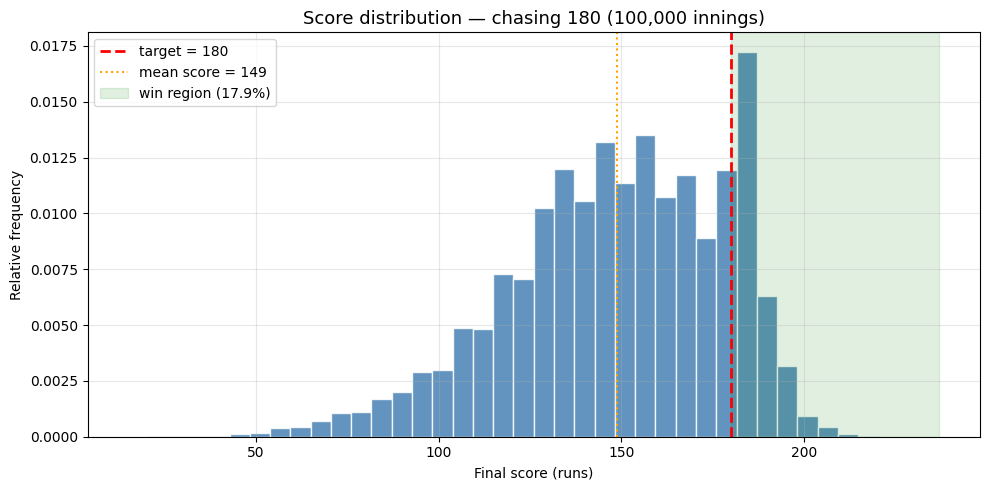

mean: 148.8  |  std: 29.5  |  range: 15–237


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(final_scores, bins=40, color='steelblue', edgecolor='white', alpha=0.85, density=True)
ax.axvline(TARGET, color='red', linestyle='--', linewidth=2, label=f'target = {TARGET}')
ax.axvline(final_scores.mean(), color='orange', linestyle=':', linewidth=1.5,
           label=f'mean score = {final_scores.mean():.0f}')

ymax = ax.get_ylim()[1]
ax.fill_betweenx([0, ymax], TARGET, final_scores.max(), alpha=0.12, color='green', label=f'win region ({P_win*100:.1f}%)')
ax.set_ylim(0, ymax)

ax.set_title(f'Score distribution — chasing {TARGET} ({N_TRIALS:,} innings)', fontsize=13)
ax.set_xlabel('Final score (runs)')
ax.set_ylabel('Relative frequency')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'mean: {final_scores.mean():.1f}  |  std: {final_scores.std():.1f}  |  range: {final_scores.min():.0f}–{final_scores.max():.0f}')

### Convergence — Law of Large Numbers in action

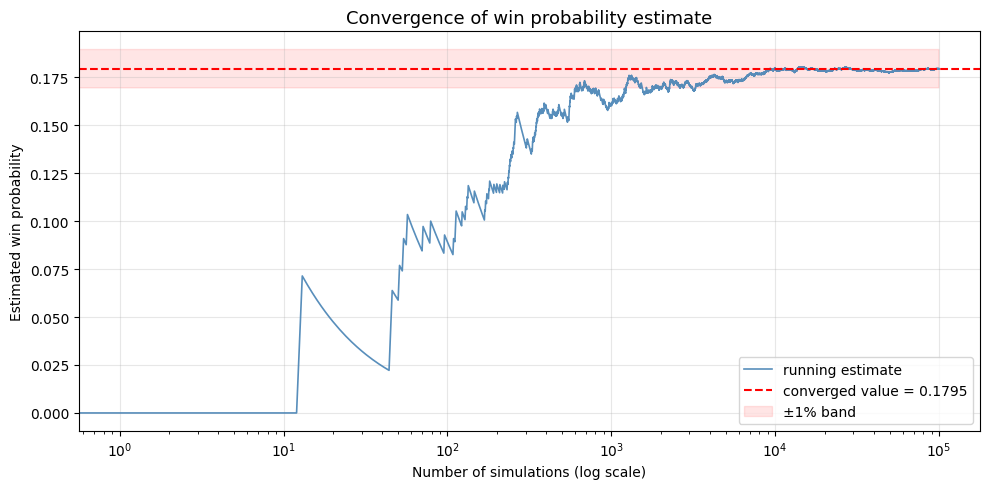

In [7]:
running_estimate = np.cumsum(outcomes == 1) / np.arange(1, N_TRIALS + 1)

plt.figure(figsize=(10, 5))
plt.plot(running_estimate, color='steelblue', linewidth=1.2, alpha=0.9, label='running estimate')
plt.axhline(P_win, color='red', linestyle='--', linewidth=1.5, label=f'converged value = {P_win:.4f}')
plt.fill_between(range(N_TRIALS), P_win - 0.01, P_win + 0.01,
                 alpha=0.1, color='red', label='±1% band')
plt.xscale('log')
plt.title('Convergence of win probability estimate', fontsize=13)
plt.xlabel('Number of simulations (log scale)')
plt.ylabel('Estimated win probability')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('convergence.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 5 — Sensitivity Analysis

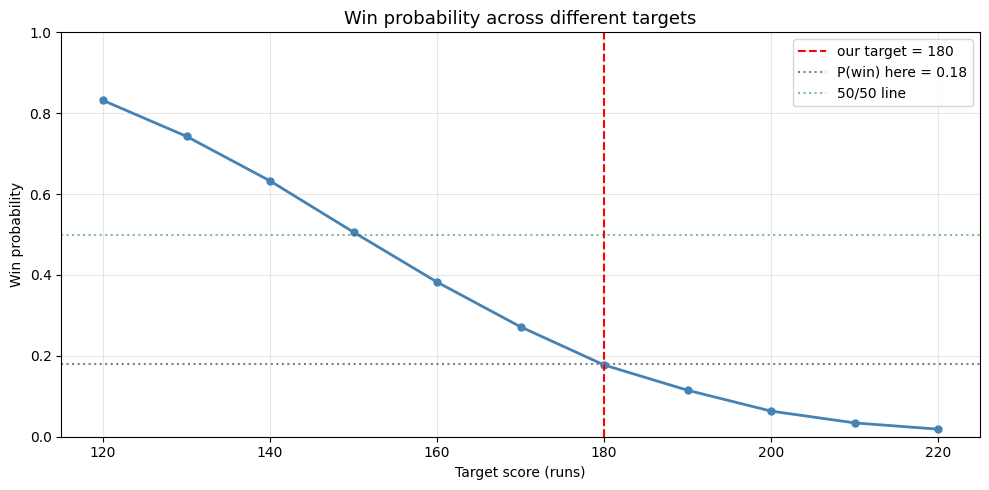

Around 150 runs is roughly a 50/50 chase under these conditions


In [8]:
targets   = range(120, 221, 10)
win_probs = []
rng2      = np.random.default_rng(42)
N_SENS    = 50_000

for tgt in targets:
    wins = 0
    for _ in range(N_SENS):
        runs    = 0
        wickets = 0
        for over in range(OVERS):
            runs    += rng2.negative_binomial(R_DISPERSION, P_NB)
            w        = rng2.poisson(LAMBDA_WICKETS)
            wickets += min(w, MAX_WICKETS - wickets)
            if runs > tgt:
                wins += 1
                break
            if wickets >= MAX_WICKETS:
                break
    win_probs.append(wins / N_SENS)

plt.figure(figsize=(10, 5))
plt.plot(list(targets), win_probs, marker='o', color='steelblue', linewidth=2, markersize=5)
plt.axvline(TARGET, color='red', linestyle='--', linewidth=1.5, label=f'our target = {TARGET}')
plt.axhline(P_win, color='gray', linestyle=':', label=f'P(win) here = {P_win:.2f}')
plt.axhline(0.5, color='green', linestyle=':', alpha=0.5, label='50/50 line')
plt.title('Win probability across different targets', fontsize=13)
plt.xlabel('Target score (runs)')
plt.ylabel('Win probability')
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

# find the target where it becomes roughly a coin flip
fifty_fifty = [t for t, p in zip(targets, win_probs) if p >= 0.48 and p <= 0.52]
if fifty_fifty:
    print(f'Around {fifty_fifty[0]} runs is roughly a 50/50 chase under these conditions')

---
## Part 6 — Try it yourself

The parameters at the top are easy to change. A few scenarios worth trying:

```python
# Strong batting lineup
MU_RUNS = 9.5
TARGET  = 180

# Batting collapse scenario
LAMBDA_WICKETS = 0.65
TARGET = 160

# High-variance T20
R_DISPERSION = 1  # more spread in run scoring
TARGET = 200
```

Go back to the parameters cell, change the values, and rerun the notebook.

---

## What this model doesn't capture

Run rate isn't constant in real cricket — teams go harder in death overs, slow down after early wickets. No powerplay effect, no batting order, no match-pressure adjustments. The simulation also checks win condition after each over, not ball-by-ball.

A more realistic version would vary the distribution parameters by over number — lower wicket rate in powerplay, higher run rate in overs 16–20. That's the obvious next step.

---
*Built while studying probability distributions in Probability and Statistics course at IIT Kanpur. The course covers the math — cricket made it worth actually thinking about.*